In [1]:
# Task 1 & 2

import time
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
from collections import deque, defaultdict
import heapq
%load_ext memory_profiler

class Graph:
    def __init__(self, vertices):
        self.V = vertices
        self.adj_list = defaultdict(list)
        self.edges = [] # For Bellman-Ford/Kruskal

    def add_edge(self, u, v, weight=0, directed=False):
        self.adj_list[u].append((v, weight))
        self.edges.append((u, v, weight))
        if not directed:
            self.adj_list[v].append((u, weight))

    # --- TASK 2: BFS & DFS (Friend Suggestion) ---
    def bfs(self, start):
        visited = set([start])
        queue = deque([start])
        result = []
        while queue:
            node = queue.popleft()
            result.append(node)
            for neighbor, _ in self.adj_list[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        return result

    def dfs(self, start, visited=None, result=None):
        if visited is None: visited, result = set(), []
        visited.add(start)
        result.append(start)
        for neighbor, _ in self.adj_list[start]:
            if neighbor not in visited:
                self.dfs(neighbor, visited, result)
        return result

g = Graph(5)
g.add_edge(0, 1); g.add_edge(0, 2); g.add_edge(1, 3); g.add_edge(2, 4)
print("BFS:", g.bfs(0))
print("DFS:", g.dfs(0))

BFS: [0, 1, 2, 3, 4]
DFS: [0, 1, 3, 2, 4]


In [3]:
# Task 3

def topological_sort(graph):
    in_degree = {i: 0 for i in range(graph.V)}
    for u in graph.adj_list:
        for v, _ in graph.adj_list[u]:
            in_degree[v] += 1
            
    queue = deque([i for i in range(graph.V) if in_degree[i] == 0])
    topo_order = []
    
    while queue:
        u = queue.popleft()
        topo_order.append(u)
        for v, _ in graph.adj_list[u]:
            in_degree[v] -= 1
            if in_degree[v] == 0:
                queue.append(v)
    return topo_order

g_topo = Graph(6)
g_topo.add_edge(5, 2, directed=True); g_topo.add_edge(5, 0, directed=True)
g_topo.add_edge(4, 0, directed=True); g_topo.add_edge(4, 1, directed=True)
g_topo.add_edge(2, 3, directed=True); g_topo.add_edge(3, 1, directed=True)
print("Topological Sort:", topological_sort(g_topo))

Topological Sort: [4, 5, 2, 0, 3, 1]


In [5]:
# Task 4

def dijkstra(graph, start):
    distances = {node: float('inf') for node in range(graph.V)}
    distances[start] = 0
    pq = [(0, start)]
    
    while pq:
        curr_dist, curr_node = heapq.heappop(pq)
        if curr_dist > distances[curr_node]: continue
            
        for neighbor, weight in graph.adj_list[curr_node]:
            dist = curr_dist + weight
            if dist < distances[neighbor]:
                distances[neighbor] = dist
                heapq.heappush(pq, (dist, neighbor))
    return distances

def bellman_ford(graph, start):
    distances = {node: float('inf') for node in range(graph.V)}
    distances[start] = 0
    for _ in range(graph.V - 1):
        for u, v, w in graph.edges:
            if distances[u] != float('inf') and distances[u] + w < distances[v]:
                distances[v] = distances[u] + w
    # Check for negative cycles
    for u, v, w in graph.edges:
        if distances[u] != float('inf') and distances[u] + w < distances[v]:
            return "Graph contains negative weight cycle"
    return distances

g_path = Graph(5)
g_path.add_edge(0, 1, -1, True); g_path.add_edge(0, 2, 4, True)
g_path.add_edge(1, 2, 3, True); g_path.add_edge(1, 3, 2, True)
g_path.add_edge(1, 4, 2, True); g_path.add_edge(3, 2, 5, True); g_path.add_edge(3, 1, 1, True); g_path.add_edge(4, 3, -3, True)
print("Dijkstra (Emergency):", dijkstra(g_path, 0))
print("Bellman-Ford (Negative Edges):", bellman_ford(g_path, 0))

Dijkstra (Emergency): {0: 0, 1: -1, 2: 2, 3: -2, 4: 1}
Bellman-Ford (Negative Edges): {0: 0, 1: -1, 2: 2, 3: -2, 4: 1}


Kruskal MST: [(2, 3, 4), (0, 3, 5), (0, 1, 10)]


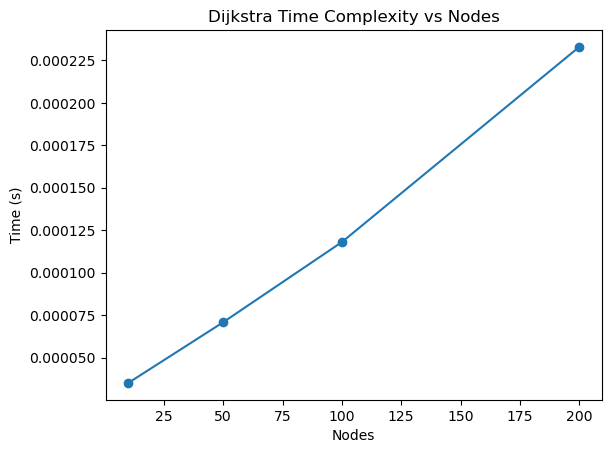

In [7]:
# Task - 5

class DisjointSet:
    def __init__(self, vertices):
        self.parent = {i: i for i in range(vertices)}
    def find(self, item):
        if self.parent[item] == item: return item
        self.parent[item] = self.find(self.parent[item])
        return self.parent[item]
    def union(self, set1, set2):
        root1, root2 = self.find(set1), self.find(set2)
        if root1 != root2: self.parent[root1] = root2

def kruskal_mst(graph):
    result = []
    i, e = 0, 0
    graph.edges = sorted(graph.edges, key=lambda item: item[2])
    ds = DisjointSet(graph.V)
    
    while e < graph.V - 1 and i < len(graph.edges):
        u, v, w = graph.edges[i]
        i += 1
        x, y = ds.find(u), ds.find(v)
        if x != y:
            e += 1
            result.append((u, v, w))
            ds.union(x, y)
    return result

g_mst = Graph(4)
g_mst.add_edge(0, 1, 10); g_mst.add_edge(0, 2, 6); g_mst.add_edge(0, 3, 5); g_mst.add_edge(1, 3, 15); g_mst.add_edge(2, 3, 4)
print("Kruskal MST:", kruskal_mst(g_mst))

# --- PROFILING ---
sizes = [10, 50, 100, 200]
times = []
for n in sizes:
    tg = Graph(n)
    for i in range(n-1): tg.add_edge(i, i+1, 1)
    start = time.time()
    dijkstra(tg, 0)
    times.append(time.time() - start)

plt.plot(sizes, times, marker='o')
plt.title('Dijkstra Time Complexity vs Nodes')
plt.xlabel('Nodes'); plt.ylabel('Time (s)')
plt.show()

## 3.6 Reflection & Discussion

* **Algorithm Suitability:** Dijkstra's algorithm benefited the emergency path routing problem the most because it guarantees the shortest path in a graph with non-negative edge weights efficiently using a priority queue.
* **Complexity vs. Scalability:** BFS/DFS run in $O(V+E)$. On sparse networks, they are highly efficient. On dense networks, memory can become a bottleneck. Bellman-Ford runs in $O(V \times E)$, making it extremely slow for large, dense graphs compared to Dijkstra.
* **Infrastructure Impact:** For MST (cabling), Kruskal's algorithm (sorting edges) is often better for sparse networks, while Prim's (growing a tree from a vertex) can be more efficient for dense networks, directly impacting calculation speed for large infrastructure planning.
* **Edge Case Handling:** Negative weight cycles in route planning cause infinite loops where paths get endlessly "shorter." Bellman-Ford addresses this by iterating exactly $V-1$ times and doing one final check to detect if distances still update.
* **Extensibility:** **Supply Chain Logistics:** Modeling warehouses as nodes and shipping routes as edges. The **Ford-Fulkerson algorithm** would be best suited to find the maximum flow of goods through the network.